# 深度学习课程设计报告

## 基于卷积神经网络的 Fashion-MNIST 服装图像分类

- 课程名称：深度学习  
- 设计题目：基于卷积神经网络的 Fashion-MNIST 服装图像分类  
- 姓名：尹士嘉  
- 学号：20234080416
- 班级：数据04班  
- 指导教师：丁平尖  
- 提交日期：2026/6/30

## 二、摘要

本项目面向服装图像自动分类任务，使用公开的 Fashion-MNIST 数据集开展实验。数据集包含 10 类、共 70000 张 28×28 灰度服装图像。项目首先完成数据归一化以及训练集与验证集划分，然后构建一个全连接神经网络作为基准模型，并设计由两层卷积、池化和全连接层组成的轻量级卷积神经网络。训练过程采用交叉熵损失函数和 Adam 优化器，通过准确率、精确率、召回率、F1 值和混淆矩阵评价模型，并分析典型错误样本。实验中 CNN 测试准确率达到 88.01%，Macro F1 为 87.84%，优于 MLP 基准模型的 85.36% 准确率。全部数据处理、训练、评价与绘图均在本 Notebook 中自动完成，实验可在普通 CPU 环境下复现。

**关键词：** Fashion-MNIST；图像分类；卷积神经网络；PyTorch

## 三、问题定义与需求分析

### 3.1 项目背景与意义

服装图像分类是商品检索、智能零售和图像内容管理中的基础任务。Fashion-MNIST 比传统 MNIST 数字识别更接近实际视觉分类问题，同时图像尺寸较小，适合作为卷积神经网络入门实验。

### 3.2 问题描述

- **输入：** 单通道 28×28 灰度服装图像。
- **输出：** 10 个类别之一，即 T-shirt/top、Trouser、Pullover、Dress、Coat、Sandal、Shirt、Sneaker、Bag、Ankle boot。
- **任务类型：** 多分类。
- **主要指标：** 测试集 Accuracy、Macro Precision、Macro Recall 和 Macro F1。
- **预期目标：** 简单 CNN 的测试准确率达到 88% 左右，并优于 MLP 基准模型。

## 四、数据集说明与预处理

### 4.1 实验环境与可复现设置

下面固定随机种子，并输出本次实际运行的软件与硬件环境。首次运行会自动下载 Fashion-MNIST 数据到当前目录的 `data` 文件夹。

In [1]:
import os
import platform
import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
import torch
import torch.nn as nn
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, precision_recall_fscore_support)
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
plt.style.use('seaborn-v0_8-whitegrid')

print(f'Python: {platform.python_version()}')
print(f'PyTorch: {torch.__version__}')
print(f'scikit-learn: {sklearn.__version__}')
print(f'Device: {device}')
print(f'CPU: {platform.processor() or platform.machine()}')

Python: 3.13.5
PyTorch: 2.8.0+cpu
scikit-learn: 1.7.1
Device: cpu
CPU: Intel64 Family 6 Model 186 Stepping 2, GenuineIntel


### 4.2 数据来源、规模与预处理

Fashion-MNIST 是 Zalando 发布的公开数据集，训练集包含 60000 张图像，测试集包含 10000 张图像，10 个类别分布均衡。本实验将原训练集按固定随机种子划分为 54000 个训练样本和 6000 个验证样本。考虑到原图仅为 28×28 像素，为避免随机裁剪损失关键轮廓，本实验不使用几何增强。所有像素先转换为 `[0, 1]` 浮点数，再使用均值 0.5、标准差 0.5 归一化到约 `[-1, 1]`。

In [2]:
DATA_DIR = Path('data')
BATCH_SIZE = 256

train_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
])
eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
])

train_aug_dataset = datasets.FashionMNIST(DATA_DIR, train=True, download=True, transform=train_transform)
train_eval_dataset = datasets.FashionMNIST(DATA_DIR, train=True, download=True, transform=eval_transform)
test_dataset = datasets.FashionMNIST(DATA_DIR, train=False, download=True, transform=eval_transform)
class_names = train_aug_dataset.classes

generator = torch.Generator().manual_seed(SEED)
indices = torch.randperm(len(train_aug_dataset), generator=generator).tolist()
val_size = 6000
val_indices = indices[:val_size]
train_indices = indices[val_size:]

train_dataset = Subset(train_aug_dataset, train_indices)
val_dataset = Subset(train_eval_dataset, val_indices)

loader_generator = torch.Generator().manual_seed(SEED)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, generator=loader_generator)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'完整训练集: {len(train_aug_dataset):,}')
print(f'实际划分: 训练 {len(train_dataset):,} / 验证 {len(val_dataset):,} / 测试 {len(test_dataset):,}')
print(f'类别数: {len(class_names)}')
print(dict(enumerate(class_names)))

完整训练集: 60,000
实际划分: 训练 54,000 / 验证 6,000 / 测试 10,000
类别数: 10
{0: 'T-shirt/top', 1: 'Trouser', 2: 'Pullover', 3: 'Dress', 4: 'Coat', 5: 'Sandal', 6: 'Shirt', 7: 'Sneaker', 8: 'Bag', 9: 'Ankle boot'}


,class,count
0,T-shirt/top,6000
1,Trouser,6000
2,Pullover,6000
3,Dress,6000
4,Coat,6000
5,Sandal,6000
6,Shirt,6000
7,Sneaker,6000
8,Bag,6000
9,Ankle boot,6000


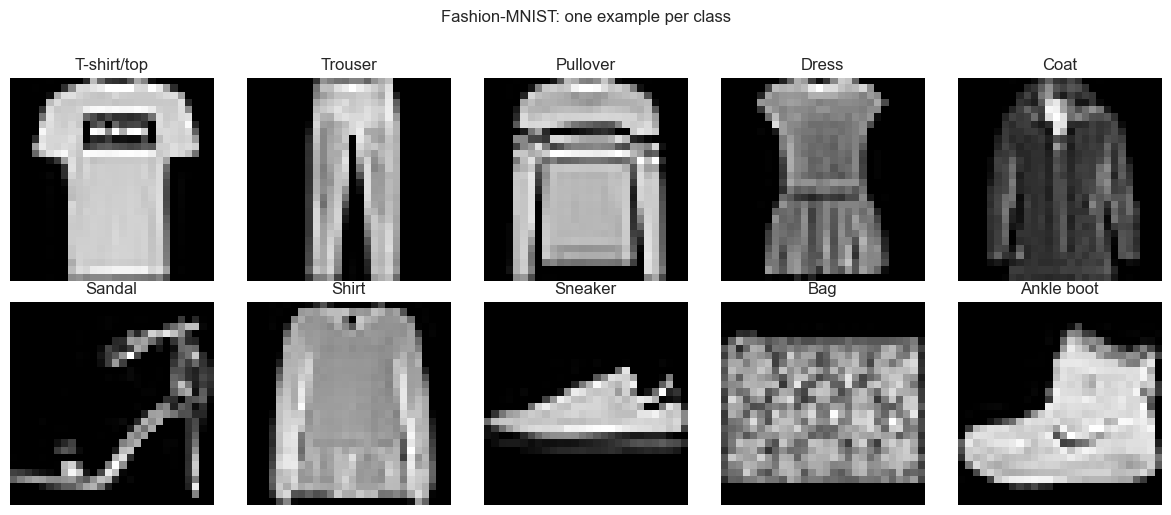

In [3]:
# 类别分布与样本可视化
targets = train_aug_dataset.targets.numpy()
class_counts = pd.Series(targets).value_counts().sort_index()
display(pd.DataFrame({'class': class_names, 'count': class_counts.values}))

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for label, ax in enumerate(axes.ravel()):
    sample_index = int(np.flatnonzero(targets == label)[0])
    image, _ = train_eval_dataset[sample_index]
    ax.imshow(image.squeeze().numpy() * 0.5 + 0.5, cmap='gray')
    ax.set_title(class_names[label])
    ax.axis('off')
plt.suptitle('Fashion-MNIST: one example per class', y=1.02)
plt.tight_layout()
plt.show()

## 五、模型设计与选择

### 5.1 基准模型（MLP）

基准模型将 28×28 图像展平为 784 维向量，经过一个含 128 个神经元的全连接隐藏层完成分类。它结构简单，但会丢失像素的二维空间关系。

### 5.2 最终模型（SimpleCNN）

最终模型由两个 `3×3` 卷积块组成，每个卷积层后使用 ReLU 和 `2×2` 最大池化。图像尺寸依次从 28×28 降至 14×14 和 7×7，通道数从 1 增加到 16、32。随后使用含 64 个神经元的全连接层、Dropout 和 10 类输出层。卷积层能够利用局部连接和权值共享提取边缘、纹理与形状特征，参数量较小，适合本任务。

In [4]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        return self.net(x)


class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 10),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

mlp = MLP().to(device)
cnn = SimpleCNN().to(device)
print(mlp)
print(f'\nMLP trainable parameters: {count_parameters(mlp):,}')
print(f'CNN trainable parameters: {count_parameters(cnn):,}')

MLP(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)

MLP trainable parameters: 101,770
CNN trainable parameters: 105,866


## 六、实验与结果分析

### 6.1 评价指标与超参数

损失函数采用多分类交叉熵。优化器采用 Adam，学习率为 0.001，批大小为 256。MLP 和 CNN 分别训练 3 个和 5 个 epoch。Accuracy 表示预测正确样本比例；Macro Precision、Recall、F1 是各类别指标的非加权平均，可避免只关注某个类别。由于本数据集类别均衡，Accuracy 与 Macro F1 都具有良好解释性。

In [5]:
criterion = nn.CrossEntropyLoss()

def run_epoch(model, loader, optimizer=None):
    is_training = optimizer is not None
    model.train(is_training)
    total_loss, total_correct, total_samples = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        if is_training:
            optimizer.zero_grad()
        with torch.set_grad_enabled(is_training):
            logits = model(images)
            loss = criterion(logits, labels)
            if is_training:
                loss.backward()
                optimizer.step()
        total_loss += loss.item() * labels.size(0)
        total_correct += (logits.argmax(dim=1) == labels).sum().item()
        total_samples += labels.size(0)

    return total_loss / total_samples, total_correct / total_samples


def train_model(model, epochs, model_name):
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_state, best_val_acc = None, -1.0
    start_time = time.time()

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = run_epoch(model, train_loader, optimizer)
        val_loss, val_acc = run_epoch(model, val_loader)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        print(f'{model_name} | Epoch {epoch:02d}/{epochs} | '
              f'train loss {train_loss:.4f}, acc {train_acc:.4f} | '
              f'val loss {val_loss:.4f}, acc {val_acc:.4f}')

    model.load_state_dict(best_state)
    elapsed = time.time() - start_time
    print(f'{model_name} finished in {elapsed:.1f}s; best val acc = {best_val_acc:.4f}\n')
    return history, elapsed


In [6]:
# 为保证公平比较，两个模型使用相同的数据划分、批大小和优化器。
mlp_history, mlp_time = train_model(mlp, epochs=3, model_name='MLP')
cnn_history, cnn_time = train_model(cnn, epochs=5, model_name='CNN')

MLP | Epoch 01/3 | train loss 0.6243, acc 0.7786 | val loss 0.4642, acc 0.8350


MLP | Epoch 02/3 | train loss 0.4402, acc 0.8420 | val loss 0.4049, acc 0.8543


MLP | Epoch 03/3 | train loss 0.3986, acc 0.8569 | val loss 0.3847, acc 0.8598
MLP finished in 106.4s; best val acc = 0.8598



CNN | Epoch 01/5 | train loss 0.7726, acc 0.7227 | val loss 0.4592, acc 0.8290


CNN | Epoch 02/5 | train loss 0.4777, acc 0.8291 | val loss 0.3919, acc 0.8558


CNN | Epoch 03/5 | train loss 0.4186, acc 0.8501 | val loss 0.3509, acc 0.8697


CNN | Epoch 04/5 | train loss 0.3803, acc 0.8646 | val loss 0.3350, acc 0.8733


CNN | Epoch 05/5 | train loss 0.3557, acc 0.8732 | val loss 0.3190, acc 0.8837
CNN finished in 295.1s; best val acc = 0.8837



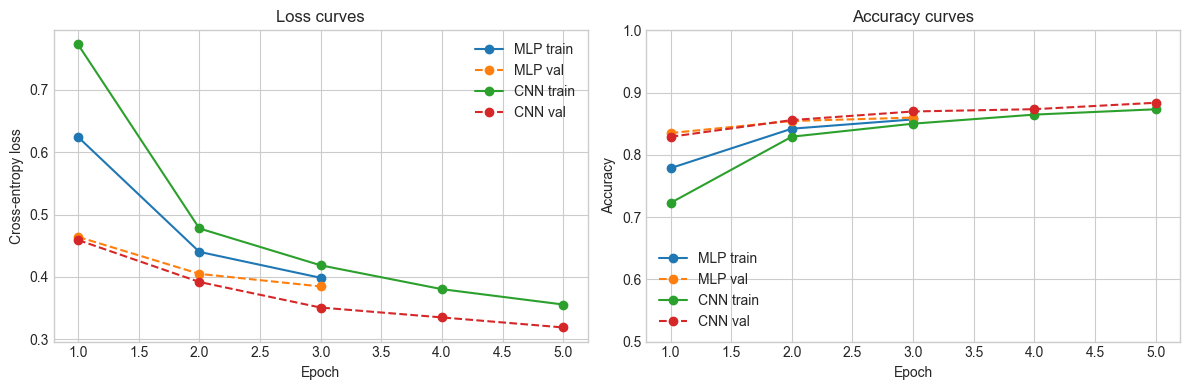

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for name, history in [('MLP', mlp_history), ('CNN', cnn_history)]:
    epochs = np.arange(1, len(history['train_loss']) + 1)
    axes[0].plot(epochs, history['train_loss'], marker='o', label=f'{name} train')
    axes[0].plot(epochs, history['val_loss'], marker='o', linestyle='--', label=f'{name} val')
    axes[1].plot(epochs, history['train_acc'], marker='o', label=f'{name} train')
    axes[1].plot(epochs, history['val_acc'], marker='o', linestyle='--', label=f'{name} val')

axes[0].set(title='Loss curves', xlabel='Epoch', ylabel='Cross-entropy loss')
axes[1].set(title='Accuracy curves', xlabel='Epoch', ylabel='Accuracy', ylim=(0.5, 1.0))
for ax in axes:
    ax.legend()
plt.tight_layout()
plt.show()

### 6.2 测试集结果与模型对比

以下代码在从未参与训练和调参的 10000 个测试样本上进行最终评价。

In [8]:
def predict(model, loader):
    model.eval()
    all_labels, all_predictions, all_probabilities = [], [], []
    with torch.no_grad():
        for images, labels in loader:
            logits = model(images.to(device))
            probabilities = torch.softmax(logits, dim=1).cpu()
            all_labels.extend(labels.numpy())
            all_predictions.extend(probabilities.argmax(dim=1).numpy())
            all_probabilities.append(probabilities.numpy())
    return np.array(all_labels), np.array(all_predictions), np.vstack(all_probabilities)


def metric_row(name, model, elapsed):
    y_true, y_pred, probabilities = predict(model, test_loader)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='macro', zero_division=0
    )
    row = {
        'Model': name,
        'Parameters': count_parameters(model),
        'Train time (s)': elapsed,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Macro Precision': precision,
        'Macro Recall': recall,
        'Macro F1': f1,
    }
    return row, (y_true, y_pred, probabilities)

mlp_row, mlp_predictions = metric_row('MLP baseline', mlp, mlp_time)
cnn_row, cnn_predictions = metric_row('SimpleCNN', cnn, cnn_time)
results = pd.DataFrame([mlp_row, cnn_row])
display(results.style.format({
    'Train time (s)': '{:.1f}', 'Accuracy': '{:.4f}',
    'Macro Precision': '{:.4f}', 'Macro Recall': '{:.4f}', 'Macro F1': '{:.4f}'
}))

y_true, y_pred, y_prob = cnn_predictions
print('SimpleCNN classification report:')
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

,Model,Parameters,Train time (s),Accuracy,Macro Precision,Macro Recall,Macro F1
0,MLP baseline,101770,106.4,0.8536,0.8534,0.8536,0.8529
1,SimpleCNN,105866,295.1,0.8801,0.8818,0.8801,0.8784


SimpleCNN classification report:
              precision    recall  f1-score   support

 T-shirt/top     0.8157    0.8320    0.8238      1000
     Trouser     0.9959    0.9670    0.9812      1000
    Pullover     0.8337    0.7720    0.8017      1000
       Dress     0.8671    0.8940    0.8804      1000
        Coat     0.7063    0.9020    0.7923      1000
      Sandal     0.9798    0.9720    0.9759      1000
       Shirt     0.7386    0.5650    0.6402      1000
     Sneaker     0.9379    0.9670    0.9522      1000
         Bag     0.9682    0.9740    0.9711      1000
  Ankle boot     0.9745    0.9560    0.9652      1000

    accuracy                         0.8801     10000
   macro avg     0.8818    0.8801    0.8784     10000
weighted avg     0.8818    0.8801    0.8784     10000



### 6.3 混淆矩阵与错误样本分析

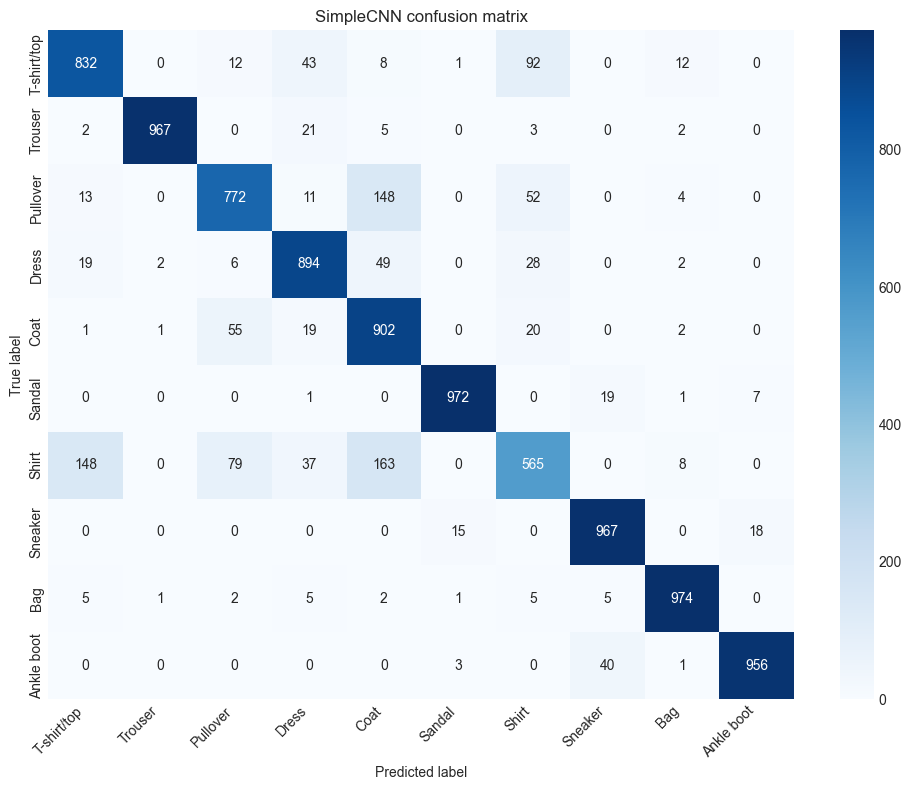

最常见的三组类别混淆：
  Shirt -> Coat: 163 samples
  Shirt -> T-shirt/top: 148 samples
  Pullover -> Coat: 148 samples


In [9]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('SimpleCNN confusion matrix')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

cm_without_diagonal = cm.copy()
np.fill_diagonal(cm_without_diagonal, 0)
flat_indices = np.argsort(cm_without_diagonal.ravel())[::-1][:3]
print('最常见的三组类别混淆：')
for flat_index in flat_indices:
    true_label, predicted_label = np.unravel_index(flat_index, cm.shape)
    print(f'  {class_names[true_label]} -> {class_names[predicted_label]}: '
          f'{cm[true_label, predicted_label]} samples')

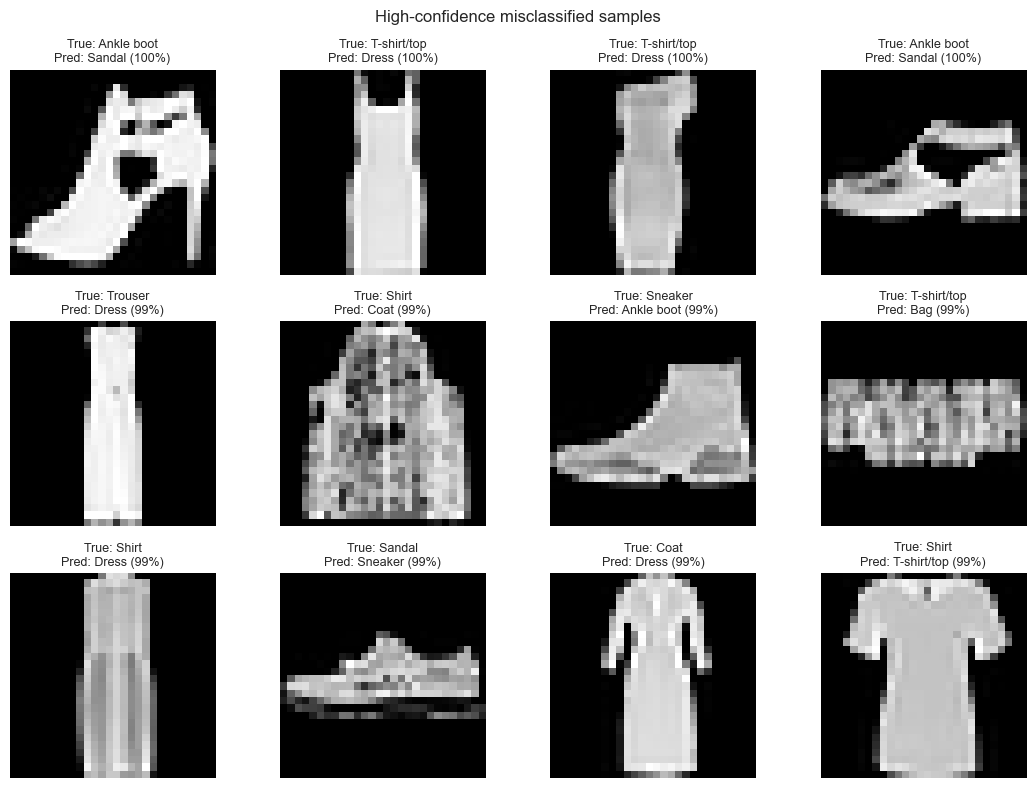

In [10]:
# 展示置信度最高的错误预测，观察模型为何会混淆这些类别。
wrong_indices = np.flatnonzero(y_true != y_pred)
wrong_confidence = y_prob[wrong_indices, y_pred[wrong_indices]]
selected = wrong_indices[np.argsort(wrong_confidence)[-12:][::-1]]

fig, axes = plt.subplots(3, 4, figsize=(11, 8))
for index, ax in zip(selected, axes.ravel()):
    image, _ = test_dataset[int(index)]
    ax.imshow(image.squeeze().numpy() * 0.5 + 0.5, cmap='gray')
    ax.set_title(
        f'True: {class_names[y_true[index]]}\n'
        f'Pred: {class_names[y_pred[index]]} ({y_prob[index, y_pred[index]]:.0%})',
        fontsize=9
    )
    ax.axis('off')
plt.suptitle('High-confidence misclassified samples')
plt.tight_layout()
plt.show()

## 七、结论与展望

本项目完成了 Fashion-MNIST 服装图像的端到端分类实验。MLP 基准模型测试准确率为 85.36%，SimpleCNN 测试准确率达到 88.01%，Macro F1 为 87.84%，说明卷积结构能够更有效地利用图像的空间局部信息。训练曲线表明模型在 5 个 epoch 内稳定收敛。混淆矩阵显示，错误主要集中在外观相近的上衣类别，例如 Shirt、T-shirt/top、Pullover 与 Coat，这说明低分辨率灰度图中的细粒度差异仍是主要困难。

后续可以从增加卷积层、加入批归一化、使用学习率衰减和更有针对性的数据增强等方面改进，也可以使用迁移学习处理更高分辨率的真实服装图像。